In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv(r"C:\Users\HEMANGI SOLANKI\Desktop\KS\sem-10\Brainybeam\BestSellerAnalytics\bestsellers_with_categories_2022_03_27.csv")

In [9]:
df.head()


,Name,Author,User_Rating,Reviews,Price,Year,Genre
0,"Act Like a Lady, Think Like a Man: What Men Re...",Steve Harvey,4.6,5013,17,2009,Non Fiction
1,Arguing with Idiots: How to Stop Small Minds a...,Glenn Beck,4.6,798,5,2009,Non Fiction
2,"Breaking Dawn (The Twilight Saga, Book 4)",Stephenie Meyer,4.6,9769,13,2009,Fiction
3,Crazy Love: Overwhelmed by a Relentless God,Francis Chan,4.7,1542,14,2009,Non Fiction
4,Dead And Gone: A Sookie Stackhouse Novel (Sook...,Charlaine Harris,4.6,1541,4,2009,Fiction


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         700 non-null    object 
 1   Author       700 non-null    object 
 2   User_Rating  700 non-null    float64
 3   Reviews      700 non-null    int64  
 4   Price        700 non-null    int64  
 5   Year         700 non-null    int64  
 6   Genre        700 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 38.4+ KB


In [11]:
df.describe()

,User_Rating,Reviews,Price,Year
count,700.000000,700.000000,700.000000,700.000000
mean,4.639857,19255.195714,12.700000,2015.500000
std,0.218586,23613.443875,9.915162,4.034011
min,3.300000,37.000000,0.000000,2009.000000
25%,4.500000,4987.250000,7.000000,2012.000000
50%,4.700000,10284.000000,11.000000,2015.500000
75%,4.800000,23358.000000,15.000000,2019.000000
max,4.900000,208917.000000,105.000000,2022.000000


In [12]:
df.isnull().sum()

Name           0
Author         0
User_Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64

In [13]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")

In [14]:
df.head()

,Name,Author,User_Rating,Reviews,Price,Year,Genre
0,"Act Like a Lady, Think Like a Man: What Men Re...",Steve Harvey,4.6,5013,17,2009,Non Fiction
1,Arguing with Idiots: How to Stop Small Minds a...,Glenn Beck,4.6,798,5,2009,Non Fiction
2,"Breaking Dawn (The Twilight Saga, Book 4)",Stephenie Meyer,4.6,9769,13,2009,Fiction
3,Crazy Love: Overwhelmed by a Relentless God,Francis Chan,4.7,1542,14,2009,Non Fiction
4,Dead And Gone: A Sookie Stackhouse Novel (Sook...,Charlaine Harris,4.6,1541,4,2009,Fiction


In [15]:
df.to_csv(r"C:\Users\HEMANGI SOLANKI\Desktop\KS\sem-10\Brainybeam\BestSellerAnalytics\bestsellers_with_categories_2022_03_27.csv", index=False)

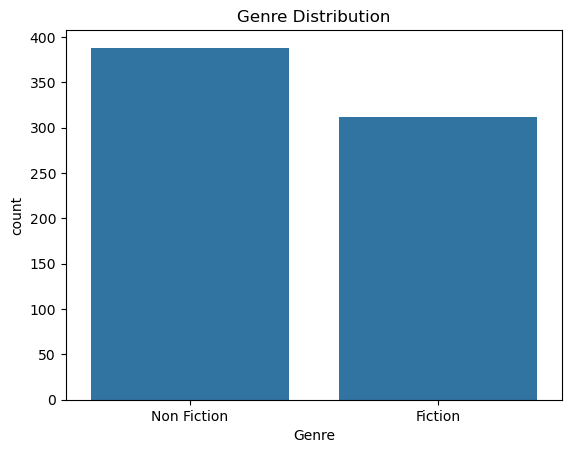

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Genre', data=df)
plt.title("Genre Distribution")
plt.show()

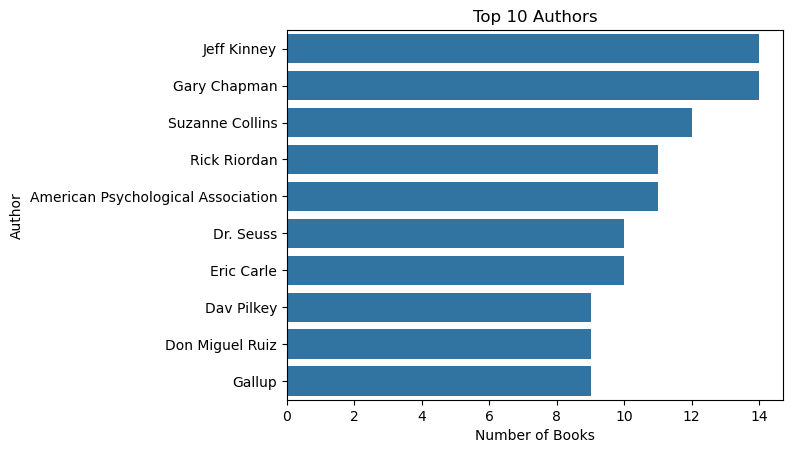

In [17]:
top_authors = df['Author'].value_counts().head(10)

sns.barplot(x=top_authors.values, y=top_authors.index)
plt.title("Top 10 Authors")
plt.xlabel("Number of Books")
plt.ylabel("Author")
plt.show()

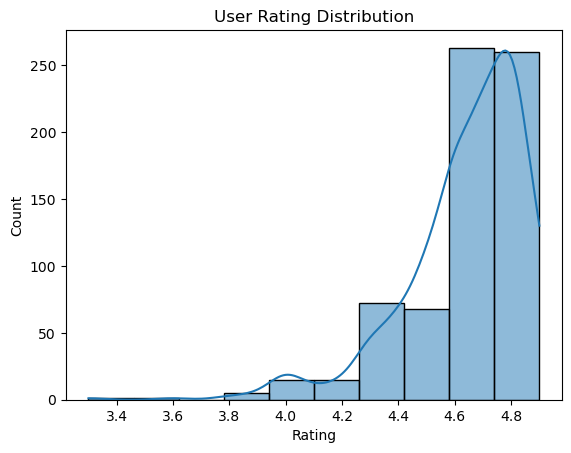

In [18]:
sns.histplot(df['User_Rating'], bins=10, kde=True)
plt.title("User Rating Distribution")
plt.xlabel("Rating")
plt.show()

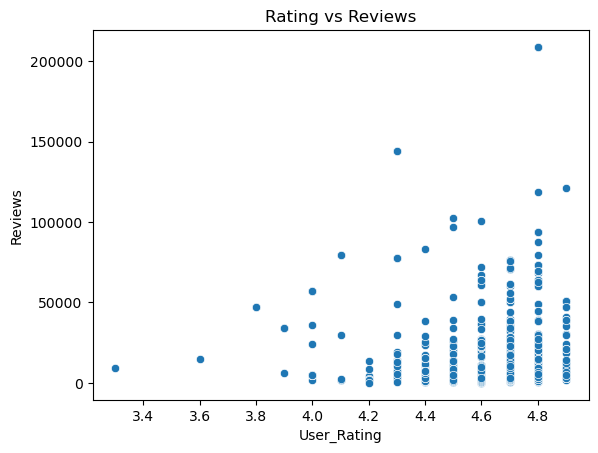

In [19]:
sns.scatterplot(x='User_Rating', y='Reviews', data=df)
plt.title("Rating vs Reviews")
plt.show()

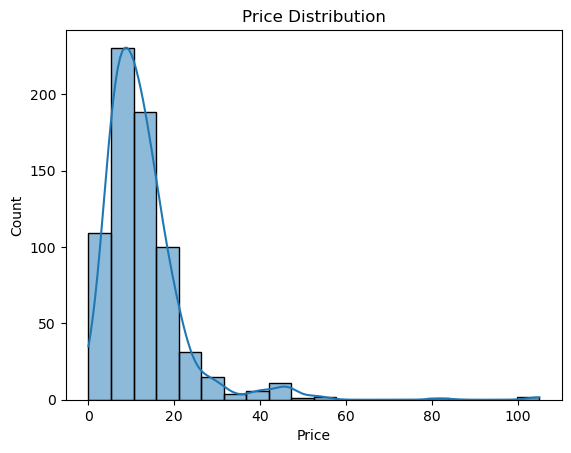

In [20]:
sns.histplot(df['Price'], bins=20, kde=True)
plt.title("Price Distribution")
plt.show()

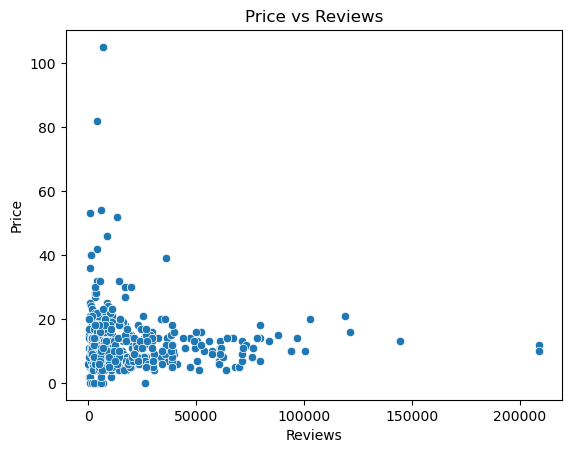

In [21]:
sns.scatterplot(x='Reviews', y='Price', data=df)
plt.title("Price vs Reviews")
plt.show()

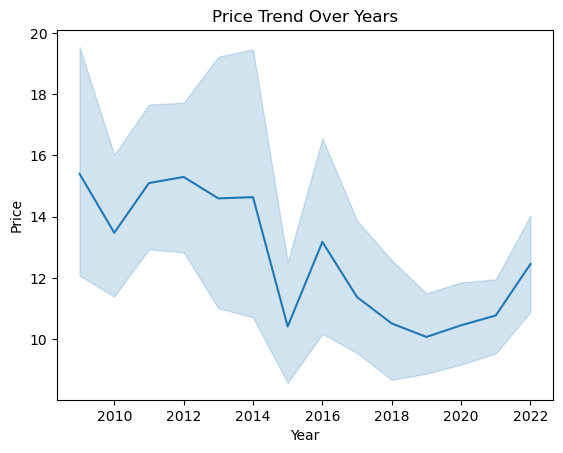

In [22]:
sns.lineplot(x='Year', y='Price', data=df)
plt.title("Price Trend Over Years")
plt.show()

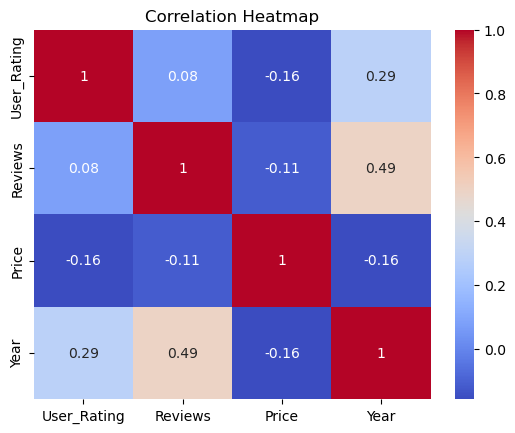

In [23]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

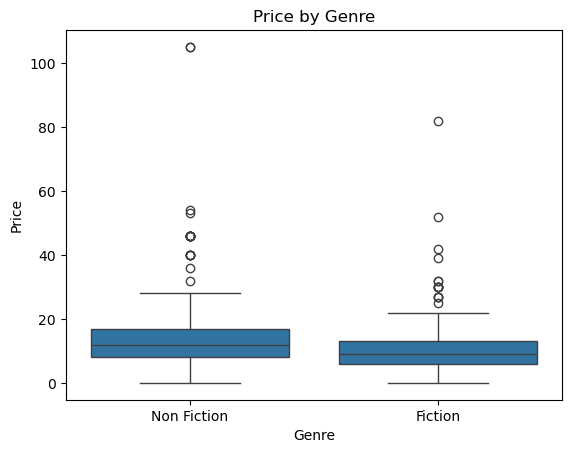

In [24]:
sns.boxplot(x='Genre', y='Price', data=df)
plt.title("Price by Genre")
plt.show()

In [25]:
X = df[['Reviews', 'User_Rating', 'Genre']]
y = df['Price']

X = pd.get_dummies(X, columns=['Genre'], drop_first=True)

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
y_pred_lr = lr_model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Price": y_test[:5],
    "Predicted Price": y_pred_rf[:5]
})

print(comparison)

     Actual Price  Predicted Price
158            10            13.64
500            12            16.79
396             9            17.61
155            14            17.13
321             8             8.06


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 5.54502826034224
RMSE: 10.274338397206543


In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("RF MAE:", mae_rf)
print("RF RMSE:", rmse_rf)

RF MAE: 3.896486989795918
RF RMSE: 6.494775033291226


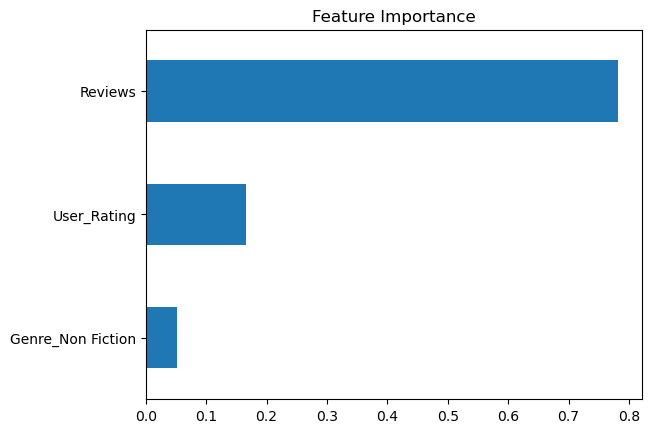

In [31]:
import pandas as pd

importance = rf_model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features)
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()